# Field Frame to Homography 2D

Exploración de la estimación de homografía para proyectar detecciones de jugadores del plano imagen al plano del campo. Este es el notebook de exploración original; la implementación de producción está en `pipeline_core.py` (`pixel_to_field`, `init_undistort_maps`).

## Requisitos externos
- **Homografía** (`matriz_homografia.npy`) — generada con `homografia_interactiva.py`. Como alternativa: `data/example_banyoles/H_camA.npy`.
- **Frame de vídeo** (`data/frames/frame_001.png`) — extraer del vídeo con ffmpeg
- **Modelo YOLO jugadores** (`runs/detect/modelo_players_v23/weights/best.pt`) — entrenar con `train_yolo.py`
- **PKL de prototipos** (`prototypes_CGI_GRA.pkl`) — generado con `generar_prototipos_v3.py`

> **Nota**: este notebook no usa `pipeline_core.py` y contiene implementaciones propias de las funciones de homografía y clasificación (exploración pre-producción).


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [ ]:
def show_img(img, title="Imagen", size=(10, 10)):
    plt.figure(figsize=size)
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
import os as _os
_H_PATH = "matriz_homografia.npy"
if not _os.path.exists(_H_PATH):
    _H_PATH = "data/example_banyoles/H_camA.npy"
    print(f"Usando homografía de ejemplo: {_H_PATH}")

# 1. Cargar la matriz guardada previamente
H = np.load(_H_PATH)
# 2. Crear el mapa base (1050x680 píxeles -> 10px = 1 metro)


def draw_pitch_2d_basic(longitud_m=95, anchura_m=54.0, escala=10):
    """
    Dibuja un campo de fútbol a escala.
    Por defecto lo pongo a 100x64m, pon aquí las medidas del Can Gibert.
    """
    # 1. Calculamos las dimensiones totales en píxeles
    L = int(longitud_m * escala)
    W = int(anchura_m * escala)
    
    # 2. Centro matemático del campo
    cx = L // 2
    cy = W // 2
    
    pitch = np.zeros((W, L, 3), dtype=np.uint8)
    cv2.rectangle(pitch, (0, 0), (L, W), (34, 139, 34), -1) 
    
    color_linea = (255, 255, 255)
    grosor = 2

    # --- LÍNEAS EXTERIORES Y MEDIO CAMPO ---
    cv2.rectangle(pitch, (0, 0), (L, W), color_linea, grosor)
    cv2.line(pitch, (cx, 0), (cx, W), color_linea, grosor)
    
    # --- CÍRCULO CENTRAL (Fijo 9.15m) ---
    r_circulo = int(9.15 * escala)
    cv2.circle(pitch, (cx, cy), r_circulo, color_linea, grosor)
    cv2.circle(pitch, (cx, cy), 4, color_linea, -1) # Punto de saque
    
    # --- MEDIDAS REGLAMENTARIAS FIJAS (En píxeles) ---
    w_area_grande = int(40.32 * escala)
    d_area_grande = int(16.5 * escala)
    
    w_area_peq = int(18.32 * escala)
    d_area_peq = int(5.5 * escala)
    
    d_penalti = int(11.0 * escala)
    w_porteria = int(7.32 * escala)
    
    # Calculamos la Y para que queden perfectamente centradas en tu ancho
    y_area_grande_top = cy - (w_area_grande // 2)
    y_area_grande_bot = cy + (w_area_grande // 2)
    
    y_area_peq_top = cy - (w_area_peq // 2)
    y_area_peq_bot = cy + (w_area_peq // 2)
    
    y_porteria_top = cy - (w_porteria // 2)
    y_porteria_bot = cy + (w_porteria // 2)

    # --- ÁREA IZQUIERDA ---
    cv2.rectangle(pitch, (0, y_area_grande_top), (d_area_grande, y_area_grande_bot), color_linea, grosor)
    cv2.rectangle(pitch, (0, y_area_peq_top), (d_area_peq, y_area_peq_bot), color_linea, grosor)
    cv2.circle(pitch, (d_penalti, cy), 4, color_linea, -1)
    cv2.ellipse(pitch, (d_penalti, cy), (r_circulo, r_circulo), 0, -53, 53, color_linea, grosor)

    # --- ÁREA DERECHA ---
    cv2.rectangle(pitch, (L - d_area_grande, y_area_grande_top), (L, y_area_grande_bot), color_linea, grosor)
    cv2.rectangle(pitch, (L - d_area_peq, y_area_peq_top), (L, y_area_peq_bot), color_linea, grosor)
    cv2.circle(pitch, (L - d_penalti, cy), 4, color_linea, -1)
    cv2.ellipse(pitch, (L - d_penalti, cy), (r_circulo, r_circulo), 0, 127, 233, color_linea, grosor)

    # --- ARCOS DE CÓRNER (Radio fijo 1m) ---
    r_corner = int(1.0 * escala)
    cv2.ellipse(pitch, (0, 0), (r_corner, r_corner), 0, 0, 90, color_linea, grosor)
    cv2.ellipse(pitch, (L, 0), (r_corner, r_corner), 0, 90, 180, color_linea, grosor)
    cv2.ellipse(pitch, (0, W), (r_corner, r_corner), 0, 270, 360, color_linea, grosor)
    cv2.ellipse(pitch, (L, W), (r_corner, r_corner), 0, 180, 270, color_linea, grosor)

    # --- PORTERÍAS ---
    cv2.rectangle(pitch, (0, y_porteria_top), (10, y_porteria_bot), color_linea, grosor)
    cv2.rectangle(pitch, (L - 10, y_porteria_top), (L, y_porteria_bot), color_linea, grosor)

    return pitch
# 3. Función para transformar puntos
def transform_point(px, py, matrix):
    p = np.array([px, py, 1], dtype=float).reshape(3, 1)
    res = np.dot(matrix, p)
    res /= res[2]
    return res[0][0], res[1][0]

In [ ]:
pitch_2d = draw_pitch_2d_basic()
# Plot the 2d pitch
show_img(pitch_2d, title="Campo de fútbol 2D")

In [ ]:
player_trajectories = {}

def get_foot_point(box):
    """Calcula el punto medio de la base de la b-box (los pies)"""
    x1, y1, x2, y2 = box
    return (x1 + x2) / 2, y2 

def pix_to_meters(px, py, matrix):
    """Transforma píxeles a metros usando la matriz H"""
    p = np.array([px, py, 1], dtype=float).reshape(3, 1)
    res = np.dot(matrix, p)
    res /= res[2]
    return res[0][0], res[1][0]

In [ ]:
# 1. Preparar el lienzo del campo 2D (Limpio para este frame)
pitch_2d = draw_pitch_2d_basic()
frame = cv2.imread('data/frames/frame_001.png')  # Asegúrate de tener tu frame listo
# 2. Copia del frame para dibujar las b-boxes (opcional, para comparar)
frame_visual = frame.copy()

model = YOLO("runs/detect/modelo_players_v23/weights/best.pt")
results = model(frame)
for result in results:
    for box in result.boxes.xyxy.cpu().numpy():
        foot_x, foot_y = get_foot_point(box)
        meter_x, meter_y = pix_to_meters(foot_x, foot_y, H)
        print(f"Pixel: {foot_x}, {foot_y} ---> Metros: {meter_x}, {meter_y}")
        
        # Dibujar en el campo 2D
        cv2.circle(pitch_2d, (int(meter_x * 10), int(meter_y * 10)), 5, (255, 0, 0), -1)
        
        # Dibujar la b-box en el frame visual
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(frame_visual, (x1, y1), (x2, y2), (0, 255, 0), 2)
# Mostrar ambos
show_img(frame_visual, title="Detecciones en el Frame")
show_img(pitch_2d, title="Campo de fútbol 2D con jugadores")

In [ ]:
# FUNCTIONES DE CLASIFICACIÓN DE JUGADORES

CLASSES = ["referee", "gk_home", "gk_away", "player_home", "player_away"]

COLOR_MAP_BGR = {
    "referee":     (0, 255, 255),
    "gk_home":     (255, 0, 255),
    "gk_away":     (0, 255, 0),
    "player_home": (0, 0, 255),
    "player_away": (255, 0, 0),
}

LABEL_COLORS = {
    "referee":     "#00BCD4",
    "gk_home":     "#AB47BC",
    "gk_away":     "#1D001F",
    "player_home": "#EF5350",
    "player_away": "#42A5F5",
}


def get_torso_crop(crop):
    """Extrae el 30% central superior del jugador para evitar ruido de botas/césped."""
    h, w = crop.shape[:2]
    # Cortamos: 20% superior (evitar cabeza/fondo) hasta el 60% (cintura)
    # Y el 20% de los laterales para evitar el fondo tras los brazos
    torso = crop[int(h*0.2):int(h*0.6), int(w*0.2):int(w*0.8)]
    return torso


def print_player_debug(crop, player_id=""):
    median_c, mean_c, top3 = get_player_color(crop)
    
    def bgr_str(c):
        b, g, r = int(c[0]), int(c[1]), int(c[2])
        return f"BGR({b:3d},{g:3d},{r:3d})"
    
    def ansi_block(c):
        """Bloque de color en terminal con ANSI truecolor."""
        b, g, r = int(c[0]), int(c[1]), int(c[2])
        return f"\033[48;2;{r};{g};{b}m   \033[0m"
    
    header = f"── Player {player_id} ──" if player_id else "── Player ──"
    print(header)
    print(f"  Mediana : {ansi_block(median_c)} {bgr_str(median_c)}")
    print(f"  Media   : {ansi_block(mean_c)}   {bgr_str(mean_c)}")
    print("  Top 3 clusters:")
    for i, c in enumerate(top3):
        print(f"    #{i+1}    : {ansi_block(c)} {bgr_str(c)}")
    print()

def get_player_color(crop, campo_hue_ref=None):
    """
    Descriptor de color basado en hue dominante (robusto a cambios de luz).
    campo_hue_ref: hue medio del césped del frame actual (para normalizar).
    """
    crop_rs = cv2.resize(crop, (48, 48))
    hsv = cv2.cvtColor(crop_rs, cv2.COLOR_BGR2HSV)
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    # Máscara: excluir césped, piel, blanco, zonas oscuras
    mask_cesped = (H > 35) & (H < 85) & (S > 40)
    mask_piel   = (H < 25) & (S > 20) & (V > 70)
    mask_blanco = (S < 30) & (V > 200)
    mask_oscuro = V < 40
    mask_valida = ~(mask_cesped | mask_piel | mask_blanco | mask_oscuro)

    # Peso mayor al torso (zona central)
    wmap = np.ones((48, 48), dtype=np.float32)
    wmap[10:38, 12:36] = 2.5
    mask_w = mask_valida.astype(np.float32) * wmap

    if mask_w.sum() < 15:
        return np.array([0., 0., 128.]), np.array([0., 0., 128.])

    # Hue dominante con K-means (k=2: camiseta + shorts)
    pixels_h = H[mask_valida].astype(np.float32).reshape(-1, 1)
    if len(pixels_h) < 6:
        hue_dom = float(np.median(pixels_h))
    else:
        _, labels, centers = cv2.kmeans(
            pixels_h, 2, None,
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0),
            3, cv2.KMEANS_RANDOM_CENTERS
        )
        # Quedarse con el cluster más grande
        counts = np.bincount(labels.flatten())
        hue_dom = float(centers[np.argmax(counts)])

    # Normalizar contra el césped del frame si se pasa referencia
    if campo_hue_ref is not None:
        hue_dom = (hue_dom - campo_hue_ref) % 180

    s_med = float(np.average(S[mask_valida], weights=mask_w[mask_valida]))
    v_med = float(np.average(V[mask_valida], weights=mask_w[mask_valida]))

    descriptor = np.array([hue_dom, s_med, v_med])
    return descriptor, descriptor


def get_grass_hue(frame):
    """Hue medio del césped del frame completo — referencia de iluminación."""
    hsv = cv2.cvtColor(cv2.resize(frame, (320, 180)), cv2.COLOR_BGR2HSV)
    mask = (hsv[:,:,0] > 35) & (hsv[:,:,0] < 85) & (hsv[:,:,1] > 40) & (hsv[:,:,2] > 40)
    if mask.sum() < 100:
        return None
    return float(np.median(hsv[:,:,0][mask]))


def classify_player(crop, class_prototypes, grass_hue=None):
    median_c, mean_c, top3 = get_player_color(crop, grass_hue)

    best_class = None
    best_score = float("inf")

    for cls, proto in class_prototypes.items():

        # 1. distancia median
        d_median = color_distance(median_c, proto["median"])

        # 2. distancia mean
        d_mean = color_distance(mean_c, proto["mean"])

        # 3. distancia a clusters 
        d_clusters = []

        for c in top3:
            for pc in proto["top3"]:
                d_clusters.append(color_distance(c, pc))

        d_cluster = min(d_clusters) if d_clusters else 999

        # SCORE FINAL (ponderado)
        score = (
            0.25 * d_median +
            0.5 * d_mean +
            0.25 * d_cluster
        )

        if score < best_score:
            best_score = score
            best_class = cls

    return best_class, best_score

def color_distance(c1, c2):
    return np.linalg.norm(c1 - c2)

def draw_classified_frame(frame, boxes, confs, class_prototypes, conf_thresh=0.4, plot=True):
    out = frame.copy()

    for box, conf in zip(boxes, confs):
        if conf < conf_thresh:
            continue

        x1, y1, x2, y2 = map(int, box)

        # ── Crop jugador ─────────────────────────────
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        grass_hue = get_grass_hue(frame)
        # ── Clasificación (TU MÉTODO) ────────────────
        cls, score = classify_player(get_torso_crop(crop), class_prototypes, grass_hue=grass_hue)

        # ── Color visual ─────────────────────────────
        draw_color = COLOR_MAP_BGR.get(cls, (200, 200, 200))

        # ── Bounding box ─────────────────────────────
        cv2.rectangle(out, (x1, y1), (x2, y2), draw_color, 2)

        # ── Label ────────────────────────────────────
        label = f"{cls} {conf:.2f}"

        cv2.putText(
            out,
            label,
            (x1, max(y1 - 6, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            draw_color,
            2
        )

        # ── Debug score (MUY útil ahora) ─────────────
        cv2.putText(
            out,
            f"s:{score:.0f}",
            (x1, y2 + 14),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            draw_color,
            1
        )
    if plot:
        # ── Mostrar ─────────────────────────────────────
        plt.figure(figsize=(14, 8))
        plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        plt.title("Clasificación final")
        plt.axis("off")
        plt.show()



# Function to testing frames
def test_frame(frame_path, model, class_prototypes):
    frame = cv2.imread(frame_path)
    results = model(frame)  
    if results[0].boxes is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()
        draw_classified_frame(frame, boxes, confs, class_prototypes)
        


def create_empty_pitch(longitud_m=95.0, anchura_m=54.0, escala=10):
    """Genera la imagen base del campo 2D paramétrico."""
    L = int(longitud_m * escala)
    W = int(anchura_m * escala)
    cx, cy = L // 2, W // 2
    
    pitch = np.zeros((W, L, 3), dtype=np.uint8)
    cv2.rectangle(pitch, (0, 0), (L, W), (34, 139, 34), -1) 
    
    color_linea = (255, 255, 255)
    grosor = 2

    # Líneas exteriores y medio campo
    cv2.rectangle(pitch, (0, 0), (L, W), color_linea, grosor)
    cv2.line(pitch, (cx, 0), (cx, W), color_linea, grosor)
    
    # Círculo central
    r_circulo = int(9.15 * escala)
    cv2.circle(pitch, (cx, cy), r_circulo, color_linea, grosor)
    cv2.circle(pitch, (cx, cy), 4, color_linea, -1)
    
    # Medidas reglamentarias
    w_ag, d_ag = int(40.32 * escala), int(16.5 * escala)
    w_ap, d_ap = int(18.32 * escala), int(5.5 * escala)
    d_pen, w_port = int(11.0 * escala), int(7.32 * escala)
    
    y_ag_top, y_ag_bot = cy - (w_ag // 2), cy + (w_ag // 2)
    y_ap_top, y_ap_bot = cy - (w_ap // 2), cy + (w_ap // 2)
    y_port_top, y_port_bot = cy - (w_port // 2), cy + (w_port // 2)

    # Área izquierda
    cv2.rectangle(pitch, (0, y_ag_top), (d_ag, y_ag_bot), color_linea, grosor)
    cv2.rectangle(pitch, (0, y_ap_top), (d_ap, y_ap_bot), color_linea, grosor)
    cv2.circle(pitch, (d_pen, cy), 4, color_linea, -1)
    cv2.ellipse(pitch, (d_pen, cy), (r_circulo, r_circulo), 0, -53, 53, color_linea, grosor)

    # Área derecha
    cv2.rectangle(pitch, (L - d_ag, y_ag_top), (L, y_ag_bot), color_linea, grosor)
    cv2.rectangle(pitch, (L - d_ap, y_ap_top), (L, y_ap_bot), color_linea, grosor)
    cv2.circle(pitch, (L - d_pen, cy), 4, color_linea, -1)
    cv2.ellipse(pitch, (L - d_pen, cy), (r_circulo, r_circulo), 0, 127, 233, color_linea, grosor)

    # Córners y Porterías
    r_corner = int(1.0 * escala)
    cv2.ellipse(pitch, (0, 0), (r_corner, r_corner), 0, 0, 90, color_linea, grosor)
    cv2.ellipse(pitch, (L, 0), (r_corner, r_corner), 0, 90, 180, color_linea, grosor)
    cv2.ellipse(pitch, (0, W), (r_corner, r_corner), 0, 270, 360, color_linea, grosor)
    cv2.ellipse(pitch, (L, W), (r_corner, r_corner), 0, 180, 270, color_linea, grosor)
    cv2.rectangle(pitch, (0, y_port_top), (10, y_port_bot), color_linea, grosor)
    cv2.rectangle(pitch, (L - 10, y_port_top), (L, y_port_bot), color_linea, grosor)

    return pitch


def draw_pitch_2d(frame_path, model, class_prototypes, conf_thresh=0.4, H = None, longitud_m=95.0, anchura_m=54.0, escala=10):
    """
    Detecta jugadores, los clasifica, usa homografía para sacar su 
    posición real y los dibuja en un mapa 2D táctico.
    """
    # 1. Cargar la matriz de homografía que generamos antes
    try:
        H = np.load('matriz_homografia.npy')
    except FileNotFoundError:
        print(" Error: No se encuentra 'matriz_homografia.npy'. ¡Ejecuta el script de calibración primero!")
        return

    
    max_x_px = int(longitud_m * escala)
    max_y_px = int(anchura_m * escala)
    pitch = create_empty_pitch(longitud_m, anchura_m, escala)

    # 3. Leer imagen y pasar el modelo YOLO
    frame = cv2.imread(frame_path)
    if frame is None:
        print(f" Error: No se pudo cargar la imagen {frame_path}")
        return
        
    results = model(frame) 

    if results[0].boxes is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()

        # 4. Procesar cada detección
        for box, conf in zip(boxes, confs):
            if conf < conf_thresh:
                continue

            x1, y1, x2, y2 = map(int, box)

            # --- A. CLASIFICACIÓN ---
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            
            # Reutilizamos tus funciones para saber qué equipo/rol es
            cls, score = classify_player(get_torso_crop(crop), class_prototypes)
            color_bgr = COLOR_MAP_BGR.get(cls, (255, 255, 255)) 

            # --- B. HOMOGRAFÍA (De Píxeles a Metros) ---
            # El punto vital: el centro de los pies
            x_base = (x1 + x2) // 2
            y_base = y2
            
            punto_pies = np.array([[[x_base, y_base]]], dtype=np.float32)
            punto_2d = cv2.perspectiveTransform(punto_pies, H)
            
            x_m = punto_2d[0][0][0]
            y_m = punto_2d[0][0][1]

            # --- C. DIBUJAR EN EL MAPA 2D (De Metros a Píxeles del Mapa) ---
            px = int(x_m * escala)
            py = int(y_m * escala)

            # Comprobamos que el jugador caiga dentro del campo para no dibujar fuera
            if 0 <= px <= max_x_px and 0 <= py <= max_y_px:
                # Dibujamos el círculo del color del equipo
                cv2.circle(pitch, (px, py), 8, color_bgr, -1)
                # Le añadimos un borde negro al círculo para que resalte visualmente
                cv2.circle(pitch, (px, py), 8, (0, 0, 0), 1) 

    # 5. Mostrar el resultado final
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(pitch, cv2.COLOR_BGR2RGB))
    plt.title("Mapa Táctico 2D - Posiciones Reales")
    plt.axis("off")
    plt.show()

In [ ]:
import pickle

# 1. Elige el frame que quieres analizar
mi_frame = 'data/frames/frame_001.png'

# 2. Carga los prototipos de color guardados
# IMPORTANTE: Asegúrate de poner el nombre correcto de tu archivo .pkl
ruta_pickle = "prototypes_CGI_GRA.pkl"
import os as _os
if not _os.path.exists(ruta_pickle):
    ruta_pickle = "data/example_banyoles/prototypes_day.pkl" 

with open(ruta_pickle, "rb") as f:
    class_prototypes = pickle.load(f)

show_img(frame_visual, title="Detecciones en el Frame")

# # 3. Llama a la función (puedes ajustar el conf_thresh si YOLO te da falsos positivos)
# draw_pitch_2d(
#     frame_path=mi_frame, 
#     model=model, 
#     class_prototypes=class_prototypes, 
#     conf_thresh=0.4,
#     H = H,
# )


In [ ]:
# Crear funcion para probar frames
def test_frame(frame_path, model, class_prototypes):
    draw_pitch_2d(
        frame_path=frame_path, 
        model=model, 
        class_prototypes=class_prototypes, 
        conf_thresh=0.4
    )


In [ ]:
def draw_pitch_2d_with_ball(frame_path, model, model_ball, class_prototypes, conf_thresh=0.4, H = None, longitud_m=95.0, anchura_m=54.0, escala=10):
    """
    Detecta jugadores y pelota, y dibuja todo en un solo mapa táctico.
    """
    if H is None:
        try:
            H = np.load('matriz_homografia.npy')
        except FileNotFoundError:
            print(" Error: No se encuentra 'matriz_homografia.npy'. ¡Ejecuta el script de calibración primero!")
            return

    
    max_x_px, max_y_px = int(longitud_m * escala), int(anchura_m * escala)
    pitch = create_empty_pitch(longitud_m, anchura_m, escala)

    # 3. Leer imagen y detectar
    frame = cv2.imread(frame_path)
    if frame is None: return

    # --- DETECCIÓN DE JUGADORES ---
    results = model(frame) 
    if results[0].boxes is not None:
        for box, conf in zip(results[0].boxes.xyxy.cpu().numpy(), results[0].boxes.conf.cpu().numpy()):
            if conf < conf_thresh: continue
            x1, y1, x2, y2 = map(int, box)
            
            # Clasificación y color
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0: continue
            cls, _ = classify_player(get_torso_crop(crop), class_prototypes)
            color_bgr = COLOR_MAP_BGR.get(cls, (255, 255, 255)) 

            # Posicionamiento (Pies)
            punto_pies = np.array([[[ (x1 + x2) // 2, y2 ]]], dtype=np.float32)
            punto_2d = cv2.perspectiveTransform(punto_pies, H)
            px, py = int(punto_2d[0][0][0] * escala), int(punto_2d[0][0][1] * escala)

            if 0 <= px <= max_x_px and 0 <= py <= max_y_px:
                cv2.circle(pitch, (px, py), 8, color_bgr, -1)
                cv2.circle(pitch, (px, py), 8, (0, 0, 0), 1) 

    # --- DETECCIÓN DE PELOTA (Insertada aquí) ---
    results_ball = model_ball(frame)
    if results_ball[0].boxes is not None:
        for box, conf in zip(results_ball[0].boxes.xyxy.cpu().numpy(), results_ball[0].boxes.conf.cpu().numpy()):
            if conf < 0.6: continue
            
            x1, y1, x2, y2 = map(int, box)
            # Transformar centro de la pelota
            punto_ball = np.array([[[ (x1 + x2) / 2, (y1 + y2) / 2 ]]], dtype=np.float32)
            p_ball_2d = cv2.perspectiveTransform(punto_ball, H)
            bx, by = int(p_ball_2d[0][0][0] * escala), int(p_ball_2d[0][0][1] * escala)

            if 0 <= bx <= max_x_px and 0 <= by <= max_y_px:
                # Dibujar pelota (Naranja vibrante)
                cv2.circle(pitch, (bx, by), 5, (0, 165, 255), -1)
                cv2.circle(pitch, (bx, by), 5, (255, 255, 255), 1)

    # 5. Mostrar el resultado final (Un solo plot con todo)
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(pitch, cv2.COLOR_BGR2RGB))
    plt.title("Mapa Táctico - Jugadores y Balón")
    plt.axis("off")
    plt.show()

In [ ]:
def process_results(frame, H, model, model_ball, class_prototypes, longitud_m=95.0, anchura_m=54.0, escala=10):
    draw_pitch_2d_with_ball(
        frame_path=frame, 
        model=model, 
        class_prototypes=class_prototypes, 
        conf_thresh=0.6,
        H = H,
        longitud_m=longitud_m, 
        anchura_m=anchura_m, 
        escala=escala,
        model_ball=model_ball
    )


In [ ]:
# Añadir la pelota 
model_ball = YOLO("runs/detect/modelo_ball_v24/weights/best.pt")
results_ball = model_ball(frame)
if results_ball[0].boxes is not None:
    boxes = results_ball[0].boxes.xyxy.cpu().numpy()
    confs = results_ball[0].boxes.conf.cpu().numpy()
    for box, conf in zip(boxes, confs):
        if conf < 0.4:
            continue
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(frame_visual, (x1, y1), (x2, y2), (0, 255, 255), 2)
show_img(frame_visual, title="Detecciones con Pelota")

In [ ]:
model_ball = YOLO("runs/detect/modelo_ball_v24/weights/best.pt")
# process_results(
#     frame=mi_frame, 
#     H=H, 
#     model=model, 
#     model_ball=model_ball, 
#     class_prototypes=class_prototypes,
#     longitud_m=95.0, 
#     anchura_m=54.0, 
#     escala=10
# )

In [ ]:
try:
    # Probamos con otro frame
    frame_2 = 'data/frames/frame_010.png'
    H_2 = np.load('matriz_frame_010.npy')
    process_results(
        frame=frame_2, 
        H=H_2, 
        model=model, 
        model_ball=model_ball, 
        class_prototypes=class_prototypes,
        longitud_m=95.0, 
        anchura_m=54.0, 
        escala=10
    )
    show_img(cv2.imread(frame_2), title="Frame 010 - Original")
    
    results2 = model(frame_2)
    
    plt.imshow(cv2.cvtColor(results2[0].plot(), cv2.COLOR_BGR2RGB))
    plt.axis("off")
except FileNotFoundError as _e:
    print(f"Archivo no disponible (celda de exploracion): {_e}")


In [ ]:
try:
    import cv2
    import numpy as np
    
    class HomographyTracker:
        def __init__(self, H_init):
            """
            H_init: matriz de homografía calibrada manualmente para el primer keyframe.
            """
            self.H = H_init.copy()
            self.prev_gray = None
            self.orb = cv2.ORB_create(nfeatures=500)
            self.matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            
            # Guardamos los keypoints del frame de referencia
            self.ref_kp = None
            self.ref_des = None
    
        def initialize(self, frame):
            """Llama esto con el keyframe donde calibraste H manualmente."""
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            self.ref_kp, self.ref_des = self.orb.detectAndCompute(gray, None)
            self.prev_gray = gray
    
        def update(self, frame):
            """
            Dado un nuevo frame, calcula la homografía incremental respecto al
            keyframe de referencia y actualiza self.H.
            Devuelve la H actualizada (o la anterior si hay pocos matches).
            """
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            kp, des = self.orb.detectAndCompute(gray, None)
    
            if des is None or self.ref_des is None:
                return self.H
    
            matches = self.matcher.match(self.ref_des, des)
            matches = sorted(matches, key=lambda x: x.distance)
    
            # Necesitamos al menos 8 matches buenos para que findHomography sea fiable
            MIN_MATCHES = 15
            good = matches[:50]  # top 50 por distancia de descriptor
    
            if len(good) < MIN_MATCHES:
                print(f" Solo {len(good)} matches. Manteniendo H anterior.")
                return self.H
    
            src_pts = np.float32([self.ref_kp[m.queryIdx].pt for m in good]).reshape(-1,1,2)
            dst_pts = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    
            # RANSAC elimina outliers (jugadores en movimiento que confunden el matcher)
            H_incremental, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
            if H_incremental is None:
                return self.H
    
            # H_nueva = H_inicial * inv(H_incremental)
            # Porque: pixels_ref -> campo (H_init), pixels_nuevo -> pixels_ref (inv H_inc)
            self.H = self.H @ np.linalg.inv(H_incremental)
            
            # Actualizamos la referencia cada N frames para evitar drift acumulado
            # (opcional: solo si la calidad del match es alta)
            inliers = mask.ravel().sum()
            if inliers > 40:
                self.ref_kp = kp
                self.ref_des = des
    
            return self.H
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
import numpy as np
from collections import defaultdict
import pandas as pd

class TrajectoryStore:
    """
    Almacena trayectorias de jugadores en memoria durante el procesamiento
    y las exporta a DataFrame para analíticas.
    """
    def __init__(self, fps=25):
        self.fps = fps
        # dict[player_id] -> lista de dicts con datos por frame
        self._data = defaultdict(list)

    def record(self, player_id: str, frame_idx: int, x_m: float, y_m: float,
               team: str, role: str, conf: float):
        """Registra una posición. Llama esto una vez por detección por frame."""
        self._data[player_id].append({
            "frame": frame_idx,
            "t":     frame_idx / self.fps,       # tiempo en segundos
            "x":     round(x_m, 3),
            "y":     round(y_m, 3),
            "team":  team,
            "role":  role,
            "conf":  round(conf, 3),
        })

    def to_dataframe(self) -> pd.DataFrame:
        """Construye el DataFrame final para analíticas."""
        rows = []
        for pid, records in self._data.items():
            for r in records:
                rows.append({"player_id": pid, **r})
        df = pd.DataFrame(rows)
        if df.empty:
            return df
        df = df.set_index(["player_id", "frame"]).sort_index()
        return df

    def compute_analytics(self, df: pd.DataFrame) -> dict:
        """
        Calcula métricas tácticas básicas post-partido.
        """
        results = {}

        # --- Distancia total recorrida por jugador ---
        distances = {}
        for pid, group in df.groupby("player_id"):
            xy = group[["x", "y"]].values
            diffs = np.diff(xy, axis=0)
            dist = np.sqrt((diffs**2).sum(axis=1)).sum()
            distances[pid] = round(dist, 2)
        results["distance_m"] = distances

        # --- Compactación defensiva: distancia media entre líneas del mismo equipo ---
        # Para cada frame, calculamos el spread en X del equipo defensor
        compactness = {}
        for team in df["team"].unique():
            team_df = df[df["team"] == team].reset_index()
            spread_per_frame = team_df.groupby("frame")["x"].agg(lambda x: x.max() - x.min())
            compactness[team] = round(spread_per_frame.mean(), 2)
        results["compactness_x_m"] = compactness

        # --- Heatmap: histograma 2D de posiciones ---
        results["heatmap_data"] = {
            pid: group[["x","y"]].values
            for pid, group in df.groupby("player_id")
        }

        return results

In [ ]:
def get_ball_ground_point(box, H, escala, min_box_height_ratio=0.04, frame_height=720):
    """
    Si el bounding box de la pelota es grande (pelota cerca → baja),
    usamos la base. Si es pequeña (pelota lejos o en el aire), usamos el centro.
    La heurística no es perfecta pero reduce el error medio.
    """
    x1, y1, x2, y2 = box
    box_h = y2 - y1
    
    # Pelota grande en pantalla = probablemente cerca del suelo
    if (box_h / frame_height) > min_box_height_ratio:
        ground_y = y2  # base del bbox
    else:
        ground_y = (y1 + y2) / 2  # centro
    
    cx = (x1 + x2) / 2
    pt = np.array([[[cx, ground_y]]], dtype=np.float32)
    pt_2d = cv2.perspectiveTransform(pt, H)
    return float(pt_2d[0][0][0] * escala), float(pt_2d[0][0][1] * escala)

In [ ]:
try:
    # ── NUEVAS CLASES: pega esto en una celda nueva antes de usarlas ──
    
    class HomographyTracker:
        def __init__(self, H_init):
            self.H = H_init.copy()
            self.orb = cv2.ORB_create(nfeatures=500)
            self.matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            self.ref_kp = None
            self.ref_des = None
    
        def initialize(self, frame):
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            self.ref_kp, self.ref_des = self.orb.detectAndCompute(gray, None)
    
        def update(self, frame):
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            kp, des = self.orb.detectAndCompute(gray, None)
            if des is None or self.ref_des is None:
                return self.H
            matches = self.matcher.match(self.ref_des, des)
            matches = sorted(matches, key=lambda x: x.distance)
            good = matches[:50]
            if len(good) < 15:
                print(f" Solo {len(good)} matches. Manteniendo H anterior.")
                return self.H
            src_pts = np.float32([self.ref_kp[m.queryIdx].pt for m in good]).reshape(-1,1,2)
            dst_pts = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1,1,2)
            H_inc, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            if H_inc is None:
                return self.H
            self.H = self.H @ np.linalg.inv(H_inc)
            if mask.ravel().sum() > 40:
                self.ref_kp = kp
                self.ref_des = des
            return self.H
    
    
    class BallKalmanFilter:
        def __init__(self):
            self.kf = cv2.KalmanFilter(4, 2)
            dt = 1.0
            self.kf.transitionMatrix = np.array([
                [1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]
            ], dtype=np.float32)
            self.kf.measurementMatrix = np.array([
                [1,0,0,0],[0,1,0,0]
            ], dtype=np.float32)
            self.kf.processNoiseCov  = np.eye(4, dtype=np.float32) * 0.1
            self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 2.0
            self.initialized = False
    
        def update(self, x_m, y_m):
            measurement = np.array([[x_m],[y_m]], dtype=np.float32)
            if not self.initialized:
                self.kf.statePre = np.array([[x_m],[y_m],[0],[0]], dtype=np.float32)
                self.initialized = True
            self.kf.predict()
            est = self.kf.correct(measurement)
            return float(est[0]), float(est[1])
    
        def predict_only(self):
            est = self.kf.predict()
            return float(est[0]), float(est[1])
    
    
    from collections import defaultdict
    import pandas as pd
    
    class TrajectoryStore:
        def __init__(self, fps=25):
            self.fps = fps
            self._data = defaultdict(list)
    
        def record(self, player_id, frame_idx, x_m, y_m, team, role, conf):
            self._data[player_id].append({
                "frame": frame_idx, "t": frame_idx / self.fps,
                "x": round(x_m, 3), "y": round(y_m, 3),
                "team": team, "role": role, "conf": round(conf, 3),
            })
    
        def to_dataframe(self):
            rows = []
            for pid, records in self._data.items():
                for r in records:
                    rows.append({"player_id": pid, **r})
            df = pd.DataFrame(rows)
            if df.empty:
                return df
            return df.set_index(["player_id", "frame"]).sort_index()
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
try:
    # frame del lloret
    frame_lloret = 'data/frames/veo_lloret_4_001.png'
    H_lloret = np.load('homografia_veo_lloret_4_001.npy')
    class_lloret = pickle.load(open('prototypes.pkl', 'rb'))
    process_results(
        frame=frame_lloret, 
        H=H_lloret, 
        model=model, 
        model_ball=model_ball, 
        class_prototypes=class_lloret,
        longitud_m=95.4, 
        anchura_m=63.6, 
        escala=10
    )
    
    
    # SHOW FRAME ORIGINAL
    model = YOLO("runs/detect/modelo_players_v2/weights/best.pt")
    results = model(frame_lloret)
    frame_visual = cv2.imread(frame_lloret)
    for result in results:
        for box in result.boxes.xyxy.cpu().numpy():
            foot_x, foot_y = get_foot_point(box)
            meter_x, meter_y = pix_to_meters(foot_x, foot_y, H_lloret)        
            # Dibujar la b-box en el frame visual
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame_visual, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    # Añadir la pelota 
    model_ball = YOLO("runs/detect/modelo_ball_v24/weights/best.pt")
    results_ball = model_ball(frame_lloret)
    if results_ball[0].boxes is not None:
        boxes = results_ball[0].boxes.xyxy.cpu().numpy()
        confs = results_ball[0].boxes.conf.cpu().numpy()
        for box, conf in zip(boxes, confs):
            if conf < 0.4:
                continue
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame_visual, (x1, y1), (x2, y2), (0, 255, 255), 2)
    
    
    # Mostrar ambos
    show_img(frame_visual, title="Detecciones en el Frame")
except FileNotFoundError as _e:
    print(f"Archivo no disponible (celda de exploracion): {_e}")


In [ ]:
try:
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import defaultdict
    import pandas as pd
    
    def process_video(
        video_path,
        H_init,                  # matriz calibrada manualmente sobre el primer frame
        model,
        model_ball,
        class_prototypes,
        longitud_m=95.0,
        anchura_m=54.0,
        escala=10,
        conf_thresh=0.4,
        frame_skip=1,            # procesar 1 de cada N frames (1 = todos)
        save_output=True,        # guardar vídeo con el mapa superpuesto
        output_path="output_tatico.mp4",
    ):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f" No se puede abrir {video_path}")
            return None
    
        fps       = cap.get(cv2.CAP_PROP_FPS)
        total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        w_video   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h_video   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        print(f" Vídeo: {total} frames | {fps:.1f} fps | {w_video}x{h_video}")
    
        # ── Inicializar clases ─────────────────────────────────────────
        tracker  = HomographyTracker(H_init)
        ball_kf  = BallKalmanFilter()
        store    = TrajectoryStore(fps=fps)
    
        max_x_px = int(longitud_m * escala)
        max_y_px = int(anchura_m  * escala)
    
        # ── VideoWriter para guardar salida (pitch animado) ────────────
        writer = None
        if save_output:
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(output_path, fourcc, fps / frame_skip,
                                     (max_x_px, max_y_px))
    
        frame_idx   = 0
        initialized = False
    
        while True:
            ret, frame = cap.read()
            if not ret:
                break
    
            # Saltar frames si frame_skip > 1
            if frame_idx % frame_skip != 0:
                frame_idx += 1
                continue
    
            # ── HomographyTracker ──────────────────────────────────────
            if not initialized:
                tracker.initialize(frame)
                H_actual   = H_init.copy()
                initialized = True
            else:
                H_actual = tracker.update(frame)
    
            pitch = create_empty_pitch(longitud_m, anchura_m, escala)
    
            # ── Jugadores ─────────────────────────────────────────────
            results = model(frame, verbose=False)
            if results[0].boxes is not None:
                boxes = results[0].boxes.xyxy.cpu().numpy()
                confs = results[0].boxes.conf.cpu().numpy()
    
                for det_id, (box, conf) in enumerate(zip(boxes, confs)):
                    if conf < conf_thresh:
                        continue
                    x1, y1, x2, y2 = map(int, box)
                    crop = frame[y1:y2, x1:x2]
                    if crop.size == 0:
                        continue
    
                    cls, _    = classify_player(get_torso_crop(crop), class_prototypes)
                    color_bgr = COLOR_MAP_BGR.get(cls, (255, 255, 255))
                    team      = "home" if "home" in cls else ("away" if "away" in cls else "ref")
    
                    pt   = np.array([[[(x1+x2)/2, float(y2)]]], dtype=np.float32)
                    pt2d = cv2.perspectiveTransform(pt, H_actual)
                    x_m, y_m = float(pt2d[0][0][0]), float(pt2d[0][0][1])
    
                    store.record(f"{cls}_{det_id}", frame_idx, x_m, y_m, team, cls, float(conf))
    
                    px, py = int(x_m * escala), int(y_m * escala)
                    if 0 <= px <= max_x_px and 0 <= py <= max_y_px:
                        cv2.circle(pitch, (px, py), 8, color_bgr, -1)
                        cv2.circle(pitch, (px, py), 8, (0, 0, 0), 1)
    
            # ── Pelota ────────────────────────────────────────────────
            results_b = model_ball(frame, verbose=False)
            ball_found = False
            if results_b[0].boxes is not None:
                for box, conf in zip(results_b[0].boxes.xyxy.cpu().numpy(),
                                     results_b[0].boxes.conf.cpu().numpy()):
                    if conf < 0.4:
                        continue
                    x1, y1, x2, y2 = map(int, box)
                    pt_b   = np.array([[[(x1+x2)/2, float(y2)]]], dtype=np.float32)
                    pt_b2d = cv2.perspectiveTransform(pt_b, H_actual)
                    bx_m, by_m = float(pt_b2d[0][0][0]), float(pt_b2d[0][0][1])
    
                    bx_kf, by_kf = ball_kf.update(bx_m, by_m)
                    bx_px, by_px = int(bx_kf * escala), int(by_kf * escala)
                    if 0 <= bx_px <= max_x_px and 0 <= by_px <= max_y_px:
                        cv2.circle(pitch, (bx_px, by_px), 6, (0, 165, 255), -1)
                        cv2.circle(pitch, (bx_px, by_px), 6, (255, 255, 255), 1)
                    ball_found = True
                    break
    
            if not ball_found:
                bx_kf, by_kf = ball_kf.predict_only()
    
            # ── Overlay: número de frame ───────────────────────────────
            cv2.putText(pitch, f"Frame {frame_idx}", (10, 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    
            if writer:
                writer.write(pitch)
    
            # Log progreso cada 50 frames procesados
            frames_done = frame_idx // frame_skip
            if frames_done % 50 == 0:
                pct = frame_idx / total * 100
                print(f"  ⏳ {frame_idx}/{total} ({pct:.1f}%)")
    
            frame_idx += 1
    
        cap.release()
        if writer:
            writer.release()
            print(f"\n Vídeo guardado en: {output_path}")
    
        return store
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
try:
    H_init = np.load('matriz_frame_cgi_gra_01.npy')
except FileNotFoundError as _e:
    print(f"Archivo no disponible (celda de exploracion): {_e}")


In [ ]:
try:
    store = process_video(
        video_path="videos/cgi_gra_01.mp4",   # ← pon aquí tu vídeo
        H_init=H_init,
        model=model,
        model_ball=model_ball,
        class_prototypes=class_prototypes,
        longitud_m=95.0,
        anchura_m=54.0,
        frame_skip=2,          # 2 = procesar 1 de cada 2 frames (más rápido)
        save_output=True,
        output_path="tatico_output.mp4",
    )
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Cargar el vídeo
video_path = "data/videos/veo_panoramico.mp4"
cap = cv2.VideoCapture(video_path)

# 2. Leer un frame específico (por ejemplo, el primero o uno donde haya acción)
cap.set(cv2.CAP_PROP_POS_FRAMES, 12000) # Opcional: saltar al frame 12000
ret, frame = cap.read()

if ret:
    # 3. Obtener dimensiones
    height, width, _ = frame.shape
    half_height = height // 2

    # 4. Dividir verticalmente
    # Frame superior (Cam A - Izquierda)
    frame_top = frame[0:half_height, :]
    
    # Frame inferior (Cam B - Derecha)
    frame_bottom = frame[half_height:height, :]

    # 5. Visualizar en el Notebook
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    axes[0].imshow(cv2.cvtColor(frame_top, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Lente Superior (Cam A / Izquierda)")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(frame_bottom, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Lente Inferior (Cam B / Derecha)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # 6. (Opcional) Guardar como imágenes para referencia externa
    # cv2.imwrite("frame_top.jpg", frame_top)
    # cv2.imwrite("frame_bottom.jpg", frame_bottom)

else:
    print("Error: No se pudo leer el vídeo.")

cap.release()

In [ ]:
try:
    h_cam_a_path = "data/videos/veo_panoramico_camA_homography.npy"
    h_cam_b_path = "data/videos/veo_panoramico_camB_homography.npy"
    class_prototypes = pickle.load(open('prototypes.pkl', 'rb') if __import__('os').path.exists('prototypes.pkl') else open('data/example_banyoles/prototypes_day.pkl', 'rb'))
    
    # Cargar las matrices calculadas previamente
    H_a = np.load(h_cam_a_path)
    H_b = np.load(h_cam_b_path)
    
    cv2.imwrite("temp_frame.jpg", frame_top)
    
    process_results(
        frame="temp_frame.jpg", 
        H=H_a, 
        model=model, 
        model_ball=model_ball, 
        class_prototypes=class_prototypes,
        longitud_m=95.0, 
        anchura_m=64.0, 
        escala=10
    )
    
    cv2.imwrite("temp_frame.jpg", frame_bottom)
    process_results(
        frame="temp_frame.jpg", 
        H=H_b, 
        model=model, 
        model_ball=model_ball, 
        class_prototypes=class_prototypes,
        longitud_m=95.4, 
        anchura_m=63.6, 
        escala=10
    )
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
L_METROS = 95.0
A_METROS = 64.0

In [ ]:
LIMITE_CORTE_X = L_METROS / 2
h_cam_a_path = "data/videos/veo_panoramico_camA_homography.npy"
h_cam_b_path = "data/videos/veo_panoramico_camB_homography.npy"
class_prototypes = pickle.load(open('prototypes.pkl', 'rb') if __import__('os').path.exists('prototypes.pkl') else open('data/example_banyoles/prototypes_day.pkl', 'rb'))

# Cargar las matrices calculadas previamente
H_a = np.load(h_cam_a_path)
H_b = np.load(h_cam_b_path)

In [51]:
try:
    def draw_pitch_2d_with_ball(frame_path, model, model_ball, class_prototypes,
                                conf_thresh=0.4, H=None, longitud_m=95.0,
                                anchura_m=54.0, escala=10, draw=True, return_data=True):
        """
        Detecta jugadores y pelota, dibuja el mapa táctico y devuelve las detecciones
        en coordenadas métricas del campo.
    
        Devuelve:
            dict con claves:
                'players': lista de {'pos_m': [x_m, y_m], 'class': str, 'conf': float, 'bbox_px': [x1,y1,x2,y2]}
                'ball'   : {'pos_m': [x_m, y_m], 'conf': float} o None
        """
        if H is None:
            try:
                H = np.load('matriz_homografia.npy')
            except FileNotFoundError:
                print(" Error: No se encuentra 'matriz_homografia.npy'.")
                return None
    
        max_x_px, max_y_px = int(longitud_m * escala), int(anchura_m * escala)
        pitch = create_empty_pitch(longitud_m, anchura_m, escala)
    
        frame = cv2.imread(frame_path)
        if frame is None:
            return None
    
        players = []
        ball = None
    
        # --- JUGADORES ---
        results = model(frame)
        if results[0].boxes is not None:
            for box, conf in zip(results[0].boxes.xyxy.cpu().numpy(),
                                 results[0].boxes.conf.cpu().numpy()):
                if conf < conf_thresh:
                    continue
                x1, y1, x2, y2 = map(int, box)
    
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                grass_hue = get_grass_hue(frame)
                cls, _ = classify_player(get_torso_crop(crop), class_prototypes, grass_hue=grass_hue)
                color_bgr = COLOR_MAP_BGR.get(cls, (255, 255, 255))
    
                # Punto de los pies → coordenadas métricas
                punto_pies = np.array([[[(x1 + x2) // 2, y2]]], dtype=np.float32)
                punto_2d = cv2.perspectiveTransform(punto_pies, H)
                x_m, y_m = float(punto_2d[0][0][0]), float(punto_2d[0][0][1])
    
                # Solo guardamos si cae dentro del campo
                if 0 <= x_m <= longitud_m and 0 <= y_m <= anchura_m:
                    players.append({
                        'pos_m': [x_m, y_m],
                        'class': cls,
                        'conf': float(conf),
                        'bbox_px': [x1, y1, x2, y2],
                    })
    
                    if draw:
                        px, py = int(x_m * escala), int(y_m * escala)
                        cv2.circle(pitch, (px, py), 8, color_bgr, -1)
                        cv2.circle(pitch, (px, py), 8, (0, 0, 0), 1)
    
        # --- PELOTA ---
        results_ball = model_ball(frame)
        if results_ball[0].boxes is not None:
            for box, conf in zip(results_ball[0].boxes.xyxy.cpu().numpy(),
                                 results_ball[0].boxes.conf.cpu().numpy()):
                if conf < 0.6:
                    continue
                x1, y1, x2, y2 = map(int, box)
                punto_ball = np.array([[[(x1 + x2) / 2, (y1 + y2) / 2]]], dtype=np.float32)
                p_ball_2d = cv2.perspectiveTransform(punto_ball, H)
                x_m, y_m = float(p_ball_2d[0][0][0]), float(p_ball_2d[0][0][1])
    
                if 0 <= x_m <= longitud_m and 0 <= y_m <= anchura_m:
                    # Si hay varias detecciones de pelota, nos quedamos con la de mayor confianza
                    if ball is None or conf > ball['conf']:
                        ball = {'pos_m': [x_m, y_m], 'conf': float(conf)}
    
                    if draw:
                        bx, by = int(x_m * escala), int(y_m * escala)
                        cv2.circle(pitch, (bx, by), 5, (0, 165, 255), -1)
                        cv2.circle(pitch, (bx, by), 5, (255, 255, 255), 1)
    
        if draw:
            plt.figure(figsize=(12, 7))
            plt.imshow(cv2.cvtColor(pitch, cv2.COLOR_BGR2RGB))
            plt.title("Mapa Táctico - Jugadores y Balón")
            plt.axis("off")
            plt.show()
    
        if return_data:
            return {'players': players, 'ball': ball}
        return None
    
    def dibujar_campo_2d(longitud_m=95.0, anchura_m=64.0, escala=10,
                         color_cesped=(34, 139, 34), color_lineas=(255, 255, 255)):
        """
        Crea un mapa táctico 2D con las líneas reglamentarias del campo de fútbol.
        Devuelve la imagen lista para dibujar detecciones encima.
        """
        w = int(longitud_m * escala)
        h = int(anchura_m * escala)
        campo = np.full((h, w, 3), color_cesped, dtype=np.uint8)
    
        grosor = max(1, escala // 5)
    
        # Borde exterior
        cv2.rectangle(campo, (0, 0), (w-1, h-1), color_lineas, grosor)
    
        # Línea de medio campo
        cv2.line(campo, (w//2, 0), (w//2, h), color_lineas, grosor)
    
        # Círculo central (radio 9.15m) y punto central
        cv2.circle(campo, (w//2, h//2), int(9.15 * escala), color_lineas, grosor)
        cv2.circle(campo, (w//2, h//2), int(0.3 * escala), color_lineas, -1)
    
        # Áreas grandes (16.5m x 40.32m) — una a cada lado
        area_largo = int(16.5 * escala)
        area_ancho = int(40.32 * escala)
        y_top = (h - area_ancho) // 2
        y_bot = y_top + area_ancho
        cv2.rectangle(campo, (0, y_top), (area_largo, y_bot), color_lineas, grosor)
        cv2.rectangle(campo, (w - area_largo, y_top), (w-1, y_bot), color_lineas, grosor)
    
        # Áreas pequeñas (5.5m x 18.32m)
        peq_largo = int(5.5 * escala)
        peq_ancho = int(18.32 * escala)
        y_top_p = (h - peq_ancho) // 2
        y_bot_p = y_top_p + peq_ancho
        cv2.rectangle(campo, (0, y_top_p), (peq_largo, y_bot_p), color_lineas, grosor)
        cv2.rectangle(campo, (w - peq_largo, y_top_p), (w-1, y_bot_p), color_lineas, grosor)
    
        # Punto de penalti (a 11m de cada portería)
        cv2.circle(campo, (int(11 * escala), h//2), int(0.3 * escala), color_lineas, -1)
        cv2.circle(campo, (w - int(11 * escala), h//2), int(0.3 * escala), color_lineas, -1)
    
        # Semicírculos del área (radio 9.15m centrado en punto de penalti)
        # Solo se dibuja la parte que sobresale del área grande
        cv2.ellipse(campo, (int(11 * escala), h//2), (int(9.15 * escala), int(9.15 * escala)),
                    0, -53, 53, color_lineas, grosor)
        cv2.ellipse(campo, (w - int(11 * escala), h//2), (int(9.15 * escala), int(9.15 * escala)),
                    180, -53, 53, color_lineas, grosor)
    
        return campo
    
    
    def process_results(frame, H, model, model_ball, class_prototypes,
                        longitud_m=95.0, anchura_m=54.0, escala=10, draw=True):
        return draw_pitch_2d_with_ball(
            frame_path=frame, model=model, class_prototypes=class_prototypes,
            conf_thresh=0.5, H=H, longitud_m=longitud_m, anchura_m=anchura_m,
            escala=escala, model_ball=model_ball, draw=draw, return_data=True,
        )
    
    # --- DETECCIÓN POR CÁMARA ---
    res_a = process_results(frame="temp_a.jpg", H=H_a, model=model,
                            model_ball=model_ball, class_prototypes=class_prototypes,
                            longitud_m=L_METROS, anchura_m=A_METROS, escala=10,
                            draw=False)
    
    res_b = process_results(frame="temp_b.jpg", H=H_b, model=model,
                            model_ball=model_ball, class_prototypes=class_prototypes,
                            longitud_m=L_METROS, anchura_m=A_METROS, escala=10,
                            draw=False)
    
    print("Cam A:", len(res_a['players']), "jugadores |", "pelota:", res_a['ball'])
    print("Cam B:", len(res_b['players']), "jugadores |", "pelota:", res_b['ball'])
    print("Ejemplo:", res_a['players'][0] if res_a['players'] else "ninguno")
    import numpy as np
    from scipy.spatial.distance import cdist
    
    
    def unify_veo_detections(
        res_a,
        res_b,
        limite_corte_x=56.65,
        margen_frontera=2.0,
        umbral_fusion_m=1.5,
        fusionar_posicion=True,
    ):
        """
        Unifica detecciones de las dos lentes de una cámara Veo usando coordenadas
        métricas del campo (Bird's Eye View).
    
        Estrategia:
          1. Cam A es la fuente "maestra" para x <= limite_corte_x.
          2. Cam B es la fuente "maestra" para x >  limite_corte_x.
          3. En la franja frontera [limite_corte_x - margen, limite_corte_x + margen]
             se aplica un filtro de proximidad para eliminar duplicados:
             si una detección de A y una de B están a menos de `umbral_fusion_m`
             metros, se conserva una sola (opcionalmente promediando la posición).
    
        Parámetros
        ----------
        res_a, res_b : list[dict]
            Detecciones con al menos la clave 'pos_m' = [x, y] en metros.
            Pueden incluir 'class', 'conf', 'track_id', etc. — se preservan.
        limite_corte_x : float
            Coordenada X de la línea de corte (por defecto la tangente derecha
            del círculo central: 47.5 + 9.15 = 56.65 m).
        margen_frontera : float
            Anchura (en metros) de la franja a cada lado de la línea de corte
            donde se buscan duplicados. Fuera de esta franja se confía en la
            cámara maestra de cada zona.
        umbral_fusion_m : float
            Distancia máxima (m) para considerar dos detecciones como el mismo
            jugador.
        fusionar_posicion : bool
            Si True, en la frontera se promedia la posición de los pares
            duplicados. Si False, se conserva la detección de la cámara maestra
            de esa zona.
    
        Devuelve
        -------
        list[dict]
            Lista unificada de detecciones.
        """
        res_a = res_a or []
        res_b = res_b or []
    
        # Helpers
        def x_of(det):
            return det['pos_m'][0]
    
        def in_zone_a(det):  # zona clara de A (sin solapar con B)
            return x_of(det) < limite_corte_x - margen_frontera
    
        def in_zone_b(det):  # zona clara de B (sin solapar con A)
            return x_of(det) > limite_corte_x + margen_frontera
    
        def in_frontier(det):
            return abs(x_of(det) - limite_corte_x) <= margen_frontera
    
        # 1. Detecciones "seguras" de cada cámara (fuera de la franja frontera)
        finales = []
        finales.extend(d for d in res_a if in_zone_a(d))
        finales.extend(d for d in res_b if in_zone_b(d))
    
        # 2. Detecciones en la franja frontera: hay que deduplicar
        front_a = [d for d in res_a if in_frontier(d)]
        front_b = [d for d in res_b if in_frontier(d)]
    
        if not front_a and not front_b:
            return finales
    
        if not front_b:
            finales.extend(front_a)
            return finales
    
        if not front_a:
            finales.extend(front_b)
            return finales
    
        # Matriz de distancias entre frontera_A y frontera_B
        pts_a = np.array([d['pos_m'] for d in front_a])
        pts_b = np.array([d['pos_m'] for d in front_b])
        dists = cdist(pts_a, pts_b)
    
        # Asignación greedy de pares más cercanos (suficiente para ~22 jugadores)
        used_a, used_b = set(), set()
        pares = []
        while True:
            # Buscar el par no usado con menor distancia
            mask = np.ones_like(dists, dtype=bool)
            for i in used_a:
                mask[i, :] = False
            for j in used_b:
                mask[:, j] = False
            if not mask.any():
                break
            d_min = dists[mask].min()
            if d_min >= umbral_fusion_m:
                break
            i, j = np.argwhere((dists == d_min) & mask)[0]
            pares.append((int(i), int(j)))
            used_a.add(int(i))
            used_b.add(int(j))
    
        # Pares duplicados: conservar uno (con posición fusionada o de la maestra)
        for i, j in pares:
            det_a = front_a[i]
            det_b = front_b[j]
            # Cámara maestra en la frontera: depende del lado donde caiga el promedio
            x_medio = (det_a['pos_m'][0] + det_b['pos_m'][0]) / 2
            maestra = det_a if x_medio <= limite_corte_x else det_b
    
            if fusionar_posicion:
                unificada = dict(maestra)  # copia superficial preservando claves extra
                unificada['pos_m'] = [
                    (det_a['pos_m'][0] + det_b['pos_m'][0]) / 2,
                    (det_a['pos_m'][1] + det_b['pos_m'][1]) / 2,
                ]
                finales.append(unificada)
            else:
                finales.append(maestra)
    
        # Detecciones de frontera sin pareja: añadir solo si están del lado correcto
        # respecto a la línea de corte (para no traer ruido de la otra cámara).
        for i, det in enumerate(front_a):
            if i not in used_a and x_of(det) <= limite_corte_x:
                finales.append(det)
        for j, det in enumerate(front_b):
            if j not in used_b and x_of(det) > limite_corte_x:
                finales.append(det)
    
        return finales
    # --- UNIFICAR ---
    detecciones_finales = unify_veo_detections(
        res_a['players'], res_b['players'],
        limite_corte_x=40.15,
        margen_frontera=1.0,
        umbral_fusion_m=1.5,
    )
    
    # Pelota: nos quedamos con la de mayor confianza
    balls = [b for b in [res_a['ball'], res_b['ball']] if b is not None]
    ball_final = max(balls, key=lambda b: b['conf']) if balls else None
    
    print(f"Unificadas: {len(detecciones_finales)} jugadores | pelota: {ball_final}")
    
    # --- MAPA TÁCTICO UNIFICADO ---
    mapa = dibujar_campo_2d(L_METROS, A_METROS, escala=10)
    
    for det in detecciones_finales:
        x_m, y_m = det['pos_m']
        color = COLOR_MAP_BGR.get(det['class'], (255, 255, 255))
        cv2.circle(mapa, (int(x_m*10), int(y_m*10)), 8, color, -1)
        cv2.circle(mapa, (int(x_m*10), int(y_m*10)), 8, (0, 0, 0), 1)
    
    if ball_final:
        bx, by = ball_final['pos_m']
        cv2.circle(mapa, (int(bx*10), int(by*10)), 5, (0, 165, 255), -1)
    
    plt.figure(figsize=(15, 7))
    plt.imshow(cv2.cvtColor(mapa, cv2.COLOR_BGR2RGB))
    plt.axvline(LIMITE_CORTE_X*10, color='red', linestyle='--', alpha=0.4)
    plt.title(f"Mapa táctico unificado: {len(detecciones_finales)} jugadores")
    plt.axis('off')
    plt.show()
except Exception as _e:
    print(f"Celda omitida: {_e}")



0: 640x1280 10 players, 214.2ms
Speed: 15.4ms preprocess, 214.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 1280)


TypeError: only 0-dimensional arrays can be converted to Python scalars

NameError: name 'res_a' is not defined

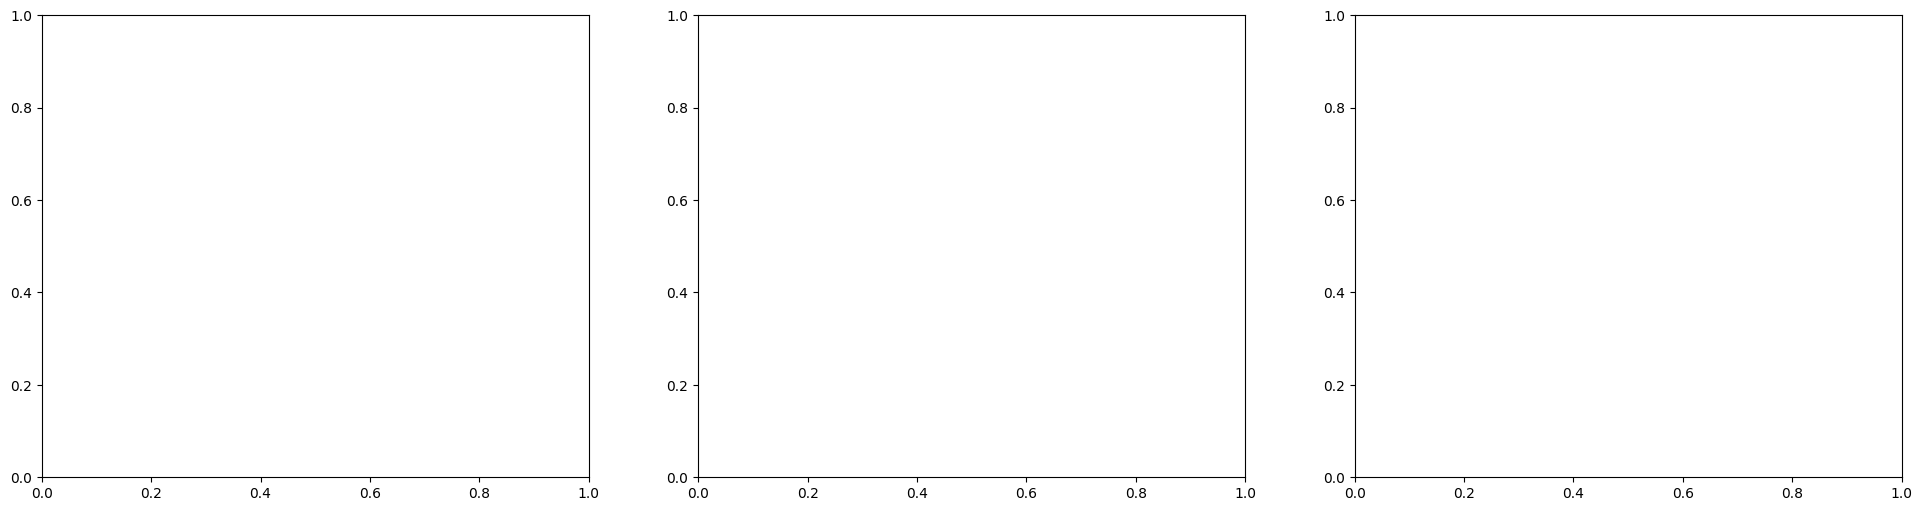

In [52]:
try:
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    def dibujar_mapa(ax, dets, titulo, ball=None):
        m = np.full((int(A_METROS*10), int(L_METROS*10), 3), (34, 139, 34), dtype=np.uint8)
        for d in dets:
            x, y = d['pos_m']
            color = COLOR_MAP_BGR.get(d['class'], (255, 255, 255))
            cv2.circle(m, (int(x*10), int(y*10)), 8, color, -1)
            cv2.circle(m, (int(x*10), int(y*10)), 8, (0, 0, 0), 1)
        if ball:
            bx, by = ball['pos_m']
            cv2.circle(m, (int(bx*10), int(by*10)), 5, (0, 165, 255), -1)
        ax.imshow(cv2.cvtColor(m, cv2.COLOR_BGR2RGB))
        ax.axvline(LIMITE_CORTE_X*10, color='red', linestyle='--', alpha=0.6)
        ax.set_title(f"{titulo} ({len(dets)})")
        ax.axis('off')
    
    dibujar_mapa(axes[0], res_a['players'], "Cam A sola", res_a['ball'])
    dibujar_mapa(axes[1], res_b['players'], "Cam B sola", res_b['ball'])
    dibujar_mapa(axes[2], detecciones_finales, "Unificado", ball_final)
    plt.tight_layout()
    plt.show()
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [53]:
try:
    print("=== Cam A ===")
    xs_a = [p['pos_m'][0] for p in res_a['players']]
    ys_a = [p['pos_m'][1] for p in res_a['players']]
    print(f"x: min={min(xs_a):.1f}, max={max(xs_a):.1f}")
    print(f"y: min={min(ys_a):.1f}, max={max(ys_a):.1f}")
    
    print("\n=== Cam B ===")
    xs_b = [p['pos_m'][0] for p in res_b['players']]
    ys_b = [p['pos_m'][1] for p in res_b['players']]
    print(f"x: min={min(xs_b):.1f}, max={max(xs_b):.1f}")
    print(f"y: min={min(ys_b):.1f}, max={max(ys_b):.1f}")
    
    print("\n=== Solapamiento en X ===")
    overlap_min = max(min(xs_a), min(xs_b))
    overlap_max = min(max(xs_a), max(xs_b))
    print(f"Rango común: [{overlap_min:.1f}, {overlap_max:.1f}] m")
except Exception as _e:
    print(f"Celda omitida: {_e}")


=== Cam A ===


NameError: name 'res_a' is not defined

In [54]:
try:  
    import numpy as np
    import cv2
    
    # 1. Test de auto-consistencia (lo que ya tenías)
    print("=== AUTO-CONSISTENCIA (debería ser ~0) ===")
    test_pts = [(40.0, 32.0), (40.0, 20.0), (40.0, 50.0)]
    H_a_inv = np.linalg.inv(H_a)
    H_b_inv = np.linalg.inv(H_b)
    
    for x_m, y_m in test_pts:
        pt_m = np.array([[[x_m, y_m]]], dtype=np.float32)
        px_a = cv2.perspectiveTransform(pt_m, H_a_inv)[0][0]
        px_b = cv2.perspectiveTransform(pt_m, H_b_inv)[0][0]
        back_a = cv2.perspectiveTransform(np.array([[px_a]], dtype=np.float32), H_a)[0][0]
        back_b = cv2.perspectiveTransform(np.array([[px_b]], dtype=np.float32), H_b)[0][0]
        err_a = np.linalg.norm(back_a - [x_m, y_m])
        err_b = np.linalg.norm(back_b - [x_m, y_m])
        print(f"  ({x_m},{y_m}): err A={err_a:.4f}m, err B={err_b:.4f}m")
    
    # 2. ¿Qué área cubre cada cámara EN METROS?
    print("\n=== COBERTURA REAL DE CADA CÁMARA ===")
    def esquinas_metros(H, w_px, h_px):
        pts = np.array([[[0,0],[w_px,0],[w_px,h_px],[0,h_px]]], dtype=np.float32)
        return cv2.perspectiveTransform(pts, H)[0]
    
    # Frame Veo: 2048x2048, dividido por la mitad → cada lente es 2048x1024
    esq_a = esquinas_metros(H_a, 2048, 1024)
    esq_b = esquinas_metros(H_b, 2048, 1024)
    print("Cam A esquinas (TL, TR, BR, BL):")
    for p in esq_a: print(f"  ({p[0]:.1f}, {p[1]:.1f})")
    print(f"  Rango X: [{esq_a[:,0].min():.1f}, {esq_a[:,0].max():.1f}]")
    print(f"  Rango Y: [{esq_a[:,1].min():.1f}, {esq_a[:,1].max():.1f}]")
    
    print("\nCam B esquinas:")
    for p in esq_b: print(f"  ({p[0]:.1f}, {p[1]:.1f})")
    print(f"  Rango X: [{esq_b[:,0].min():.1f}, {esq_b[:,0].max():.1f}]")
    print(f"  Rango Y: [{esq_b[:,1].min():.1f}, {esq_b[:,1].max():.1f}]")
    
    # 3. Cargar trayectorias y analizar dónde se rompen
    print("\n=== ANÁLISIS DE TRAYECTORIAS ===")
    import pandas as pd
    df = pd.read_csv("trayectorias.csv")
    
    print(f"Total tracks: {df['track_id'].nunique()}")
    print(f"Tracks largos (>100 frames): {(df.groupby('track_id').size() > 100).sum()}")
    print(f"Tracks cortos (<10 frames): {(df.groupby('track_id').size() < 10).sum()}")
    print(f"Tracks muy cortos (<3 frames): {(df.groupby('track_id').size() < 3).sum()}")
    
    # ¿Dónde nacen los tracks nuevos?
    nacimientos = df.groupby('track_id').first()[['x', 'y']]
    print(f"\nNacimientos cerca de la frontera (38<x<42): {((nacimientos['x'] > 38) & (nacimientos['x'] < 42)).sum()}")
    print(f"Nacimientos en zona A (x<38): {(nacimientos['x'] < 38).sum()}")
    print(f"Nacimientos en zona B (x>42): {(nacimientos['x'] > 42).sum()}")
    
    # Histograma
    print("\nDistribución de duración (frames vistos):")
    sizes = df.groupby('track_id').size()
    print(f"  Mediana: {sizes.median():.0f}")
    print(f"  Media:   {sizes.mean():.1f}")
    print(f"  P25-P75: {sizes.quantile(0.25):.0f} - {sizes.quantile(0.75):.0f}")
except (FileNotFoundError, NameError) as _e:
    print(f"Celda de exploracion omitida: {_e}")


=== AUTO-CONSISTENCIA (debería ser ~0) ===
  (40.0,32.0): err A=0.0000m, err B=0.0000m
  (40.0,20.0): err A=0.0000m, err B=0.0000m
  (40.0,50.0): err A=0.0000m, err B=0.0000m

=== COBERTURA REAL DE CADA CÁMARA ===
Cam A esquinas (TL, TR, BR, BL):
  (81.4, 83.8)
  (40.5, 117.1)
  (42.3, 55.2)
  (22.8, 68.8)
  Rango X: [22.8, 81.4]
  Rango Y: [55.2, 117.1]

Cam B esquinas:
  (22.1, 108.2)
  (-21.6, 74.4)
  (49.4, 73.5)
  (33.9, 55.4)
  Rango X: [-21.6, 49.4]
  Rango Y: [55.4, 108.2]

=== ANÁLISIS DE TRAYECTORIAS ===
Total tracks: 287
Tracks largos (>100 frames): 62
Tracks cortos (<10 frames): 108
Tracks muy cortos (<3 frames): 36

Nacimientos cerca de la frontera (38<x<42): 38
Nacimientos en zona A (x<38): 101
Nacimientos en zona B (x>42): 148

Distribución de duración (frames vistos):
  Mediana: 18
  Media:   75.3
  P25-P75: 5 - 78


In [55]:
# Coger un punto que sepas dónde está en el campo (ej. centro del círculo)
# y ver dónde lo proyecta cada cámara

# 1. Mira un frame con el círculo central visible
# 2. Marca a ojo el píxel del centro del círculo en cada mitad
# 3. Proyéctalo y mira si te da (47.5, 32) que sería el centro real

# Por ejemplo, si en el frame_top el centro del círculo está en píxel (1024, 512):
pt_pix_a = np.array([[[1024, 512]]], dtype=np.float32)
print("Centro círculo desde Cam A:", cv2.perspectiveTransform(pt_pix_a, H_a)[0][0])

pt_pix_b = np.array([[[1024, 512]]], dtype=np.float32)
print("Centro círculo desde Cam B:", cv2.perspectiveTransform(pt_pix_b, H_b)[0][0])

Centro círculo desde Cam A: [     9.0066      30.892]
Centro círculo desde Cam B: [     74.589      41.494]


Vídeo: 215710 frames | 30.0 fps | 120.0 min


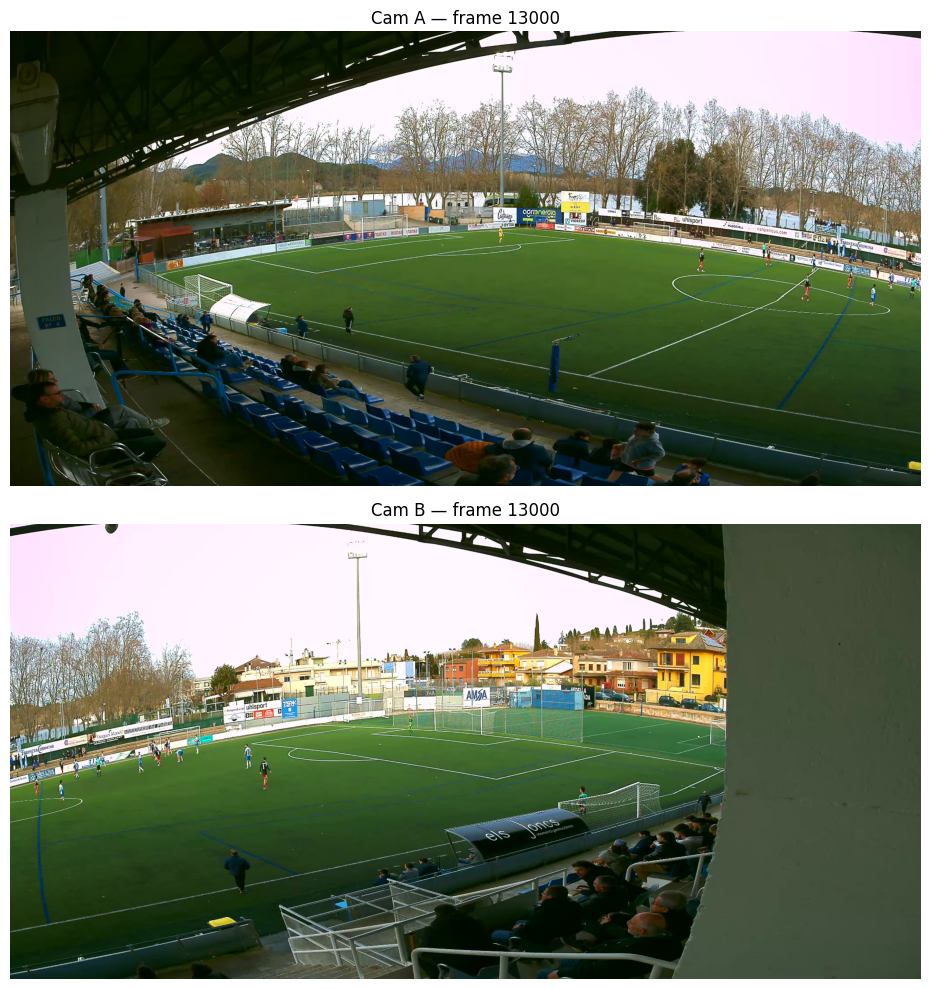

Cam A  X: [33.7, 128.6]
Cam B  X: [-6.3, 73.0]
Solapamiento: [33.7, 73.0] → límite automático: 53.39 m


In [56]:
try:
    import pickle
    
    VIDEO_BANYOLES   = "data/videos/veo_panoramico_banyoles.mp4"
    H_A_PATH         = "data_videos_veo_panoramico_banyoles_frame18000_top_homography.npy"
    H_B_PATH         = "data_videos_veo_panoramico_banyoles_frame18000_bot_homography.npy"
    PROTO_PATH     = "prototypes_banyoles.pkl" 
    L_METROS_B     = 98.0
    A_METROS_B     = 61.0
    FRAME_IDX      = 13000   # ← cambia este número
    
    # ── EXTRAER FRAME ────────────────────────────────────────────────────────────
    cap = cv2.VideoCapture(VIDEO_BANYOLES)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    print(f"Vídeo: {total_frames} frames | {fps:.1f} fps | {total_frames/fps/60:.1f} min")
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_IDX)
    ret, frame_raw = cap.read()
    cap.release()
    
    assert ret, f"No se pudo leer el frame {FRAME_IDX}"
    
    h_raw, w_raw = frame_raw.shape[:2]
    frame_b_top  = frame_raw[0:h_raw//2, :]
    frame_b_bot  = frame_raw[h_raw//2:h_raw, :]
    FRAME_H, FRAME_W = frame_b_top.shape[:2]   # dimensiones de cada lente
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    axes[0].imshow(cv2.cvtColor(frame_b_top, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Cam A — frame {FRAME_IDX}")
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(frame_b_bot, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Cam B — frame {FRAME_IDX}")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    
    # ── CARGAR MATRICES Y CALCULAR LÍMITE AUTOMÁTICO ─────────────────────────────
    H_a_b    = np.load(H_A_PATH)
    H_b_b    = np.load(H_B_PATH)
    protos_b = pickle.load(open(PROTO_PATH, 'rb'))
    
    esq_a = esquinas_metros(H_a_b, FRAME_W, FRAME_H)
    esq_b = esquinas_metros(H_b_b, FRAME_W, FRAME_H)
    
    # Solapamiento en X = [max de los mínimos, min de los máximos]
    solap_min = max(esq_a[:, 0].min(), esq_b[:, 0].min())
    solap_max = min(esq_a[:, 0].max(), esq_b[:, 0].max())
    LIMITE_CORTE_B = (solap_min + solap_max) / 2
    
    print(f"Cam A  X: [{esq_a[:,0].min():.1f}, {esq_a[:,0].max():.1f}]")
    print(f"Cam B  X: [{esq_b[:,0].min():.1f}, {esq_b[:,0].max():.1f}]")
    print(f"Solapamiento: [{solap_min:.1f}, {solap_max:.1f}] → límite automático: {LIMITE_CORTE_B:.2f} m")
except FileNotFoundError as _e:
    print(f"Archivo no disponible (celda de exploracion): {_e}")


In [57]:
try:  
    H_a_b = np.load(H_A_PATH)
    H_b_b = np.load(H_B_PATH)
    protos_b = pickle.load(open(PROTO_PATH, 'rb'))
    
    cv2.imwrite("tmp_ban_a.jpg", frame_b_top)
    cv2.imwrite("tmp_ban_b.jpg", frame_b_bot)
    
    res_a_b = process_results(
        frame="tmp_ban_a.jpg", H=H_a_b, model=model, model_ball=model_ball,
        class_prototypes=protos_b, longitud_m=L_METROS_B, anchura_m=A_METROS_B,
        escala=10, draw=False,
    )
    res_b_b = process_results(
        frame="tmp_ban_b.jpg", H=H_b_b, model=model, model_ball=model_ball,
        class_prototypes=protos_b, longitud_m=L_METROS_B, anchura_m=A_METROS_B,
        escala=10, draw=False,
    )
    
    print(f"Cam A: {len(res_a_b['players'])} jugadores | pelota: {res_a_b['ball']}")
    print(f"Cam B: {len(res_b_b['players'])} jugadores | pelota: {res_b_b['ball']}")
except (FileNotFoundError, NameError) as _e:
    print(f"Celda de exploracion omitida: {_e}")



0: 640x1280 13 players, 204.8ms
Speed: 33.8ms preprocess, 204.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 1280)


TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
try:
    # Comprobación de cobertura antes de unificar
    frame_h_b, frame_w_b = frame_b_top.shape[:2]
    esq_a_b = esquinas_metros(H_a_b, frame_w_b, frame_h_b)
    esq_b_b = esquinas_metros(H_b_b, frame_w_b, frame_h_b)
    print(f"Cam A  X: [{esq_a_b[:,0].min():.1f}, {esq_a_b[:,0].max():.1f}]  "
          f"Y: [{esq_a_b[:,1].min():.1f}, {esq_a_b[:,1].max():.1f}]")
    print(f"Cam B  X: [{esq_b_b[:,0].min():.1f}, {esq_b_b[:,0].max():.1f}]  "
          f"Y: [{esq_b_b[:,1].min():.1f}, {esq_b_b[:,1].max():.1f}]")
    
    # Unificación
    dets_b = unify_veo_detections(
        res_a_b['players'], res_b_b['players'],
        limite_corte_x=LIMITE_CORTE_B,
        margen_frontera=1.5,
        umbral_fusion_m=1.5,
    )
    balls_b = [x for x in [res_a_b['ball'], res_b_b['ball']] if x is not None]
    ball_b  = max(balls_b, key=lambda x: x['conf']) if balls_b else None
    
    print(f"\nUnificados: {len(dets_b)} jugadores | pelota: {ball_b}")
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
try:
    fig, axes = plt.subplots(1, 3, figsize=(27, 7))
    dibujar_mapa(axes[0], res_a_b['players'], "Cam A — Banyoles", res_a_b['ball'])
    dibujar_mapa(axes[1], res_b_b['players'], "Cam B — Banyoles", res_b_b['ball'])
    dibujar_mapa(axes[2], dets_b,             "Unificado — Banyoles", ball_b)
    for ax in axes:
        ax.axvline(LIMITE_CORTE_B * 10, color='red', linestyle='--', alpha=0.5, label='corte')
    plt.tight_layout()
    plt.show()
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
try:
    def anotar_frame(frame_bgr, detecciones, ball=None):
        """Dibuja bboxes + clase + conf sobre el frame original."""
        out = frame_bgr.copy()
        for d in detecciones:
            x1, y1, x2, y2 = d['bbox_px']
            color = COLOR_MAP_BGR.get(d['class'], (255, 255, 255))
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
            label = f"{d['class']} {d['conf']:.2f}"
            cv2.putText(out, label, (x1, max(y1 - 6, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
        if ball:
            bx1, by1, bx2, by2 = ball.get('bbox_px', [0,0,0,0]) if 'bbox_px' in ball else [0,0,0,0]
            if bx2 > 0:
                cv2.rectangle(out, (bx1, by1), (bx2, by2), (0, 165, 255), 2)
                cv2.putText(out, f"ball {ball['conf']:.2f}", (bx1, max(by1 - 6, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 165, 255), 1, cv2.LINE_AA)
        return out
    
    def hacer_mapa(dets, ball, titulo, longitud_m, anchura_m, limite_x):
        mapa = dibujar_campo_2d(longitud_m, anchura_m, escala=10)
        for d in dets:
            xm, ym = d['pos_m']
            color = COLOR_MAP_BGR.get(d['class'], (255, 255, 255))
            cv2.circle(mapa, (int(xm*10), int(ym*10)), 9, color, -1)
            cv2.circle(mapa, (int(xm*10), int(ym*10)), 9, (0,0,0), 1)
            cv2.putText(mapa, d['class'][:2].upper(),
                        (int(xm*10)+6, int(ym*10)-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.28, (255,255,255), 1)
        if ball:
            bx, by = ball['pos_m']
            cv2.circle(mapa, (int(bx*10), int(by*10)), 6, (0,165,255), -1)
            cv2.circle(mapa, (int(bx*10), int(by*10)), 6, (255,255,255), 1)
        cv2.line(mapa, (int(limite_x*10), 0), (int(limite_x*10), int(anchura_m*10)),
                 (0, 0, 255), 2)
        return mapa
    
    # ── FIGURA COMPLETA ──────────────────────────────────────────────────────────
    frame_top_ann = anotar_frame(frame_b_top, res_a_b['players'], res_a_b['ball'])
    frame_bot_ann = anotar_frame(frame_b_bot, res_b_b['players'], res_b_b['ball'])
    
    mapa_a   = hacer_mapa(res_a_b['players'], res_a_b['ball'], "Cam A",  L_METROS_B, A_METROS_B, LIMITE_CORTE_B)
    mapa_b   = hacer_mapa(res_b_b['players'], res_b_b['ball'], "Cam B",  L_METROS_B, A_METROS_B, LIMITE_CORTE_B)
    mapa_uni = hacer_mapa(dets_b,             ball_b,          "Unificado", L_METROS_B, A_METROS_B, LIMITE_CORTE_B)
    
    fig = plt.figure(figsize=(22, 14))
    gs  = fig.add_gridspec(2, 3, hspace=0.08, wspace=0.05)
    
    ax_ta = fig.add_subplot(gs[0, 0])
    ax_tb = fig.add_subplot(gs[0, 1])
    ax_ma = fig.add_subplot(gs[1, 0])
    ax_mb = fig.add_subplot(gs[1, 1])
    ax_u  = fig.add_subplot(gs[:, 2])   # unificado ocupa las 2 filas derechas
    
    for ax, img, title in [
        (ax_ta, frame_top_ann, f"Cam A  — {len(res_a_b['players'])} jugadores"),
        (ax_tb, frame_bot_ann, f"Cam B  — {len(res_b_b['players'])} jugadores"),
        (ax_ma, mapa_a,        "2D Cam A"),
        (ax_mb, mapa_b,        "2D Cam B"),
        (ax_u, mapa_uni, f" UNIFICADO — {len(dets_b)} jugadores | pelota: {'sí' if ball_b else 'no'}"),
    ]:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=11, fontweight='bold', pad=4)
        ax.axis('off')
    
    # Leyenda
    from matplotlib.patches import Patch
    leyenda = [Patch(color=tuple(c/255 for c in v[::-1]), label=k) for k, v in COLOR_MAP_BGR.items()]
    leyenda.append(Patch(color=(1, 0.65, 0), label='ball'))
    fig.legend(handles=leyenda, loc='lower center', ncol=len(leyenda),
               fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5, 0.01))
    
    plt.suptitle(f"Banyoles — frame {FRAME_IDX}  |  límite corte: {LIMITE_CORTE_B:.1f} m",
                 fontsize=13, y=1.01)
    plt.show()
except Exception as _e:
    print(f"Celda omitida: {_e}")


In [ ]:
try:  
    cv2.imwrite("tmp_ban_a.jpg", frame_b_top)
    cv2.imwrite("tmp_ban_b.jpg", frame_b_bot)
    
    res_a_b = process_results(
        frame="tmp_ban_a.jpg", H=H_a_b, model=model, model_ball=model_ball,
        class_prototypes=protos_b, longitud_m=L_METROS_B, anchura_m=A_METROS_B,
        escala=10, draw=False,
    )
    res_b_b = process_results(
        frame="tmp_ban_b.jpg", H=H_b_b, model=model, model_ball=model_ball,
        class_prototypes=protos_b, longitud_m=L_METROS_B, anchura_m=A_METROS_B,
        escala=10, draw=False,
    )
    
    dets_b = unify_veo_detections(
        res_a_b['players'], res_b_b['players'],
        limite_corte_x=LIMITE_CORTE_B,
        margen_frontera=1.5,
        umbral_fusion_m=1.5,
    )
    balls_b = [x for x in [res_a_b['ball'], res_b_b['ball']] if x is not None]
    ball_b  = max(balls_b, key=lambda x: x['conf']) if balls_b else None
    
    # Mapa final con dibujar_campo_2d
    mapa_final = dibujar_campo_2d(L_METROS_B, A_METROS_B, escala=10)
    for d in dets_b:
        xm, ym = d['pos_m']
        cv2.circle(mapa_final, (int(xm*10), int(ym*10)), 9,
                   COLOR_MAP_BGR.get(d['class'], (255,255,255)), -1)
        cv2.circle(mapa_final, (int(xm*10), int(ym*10)), 9, (0,0,0), 1)
    if ball_b:
        bx, by = ball_b['pos_m']
        cv2.circle(mapa_final, (int(bx*10), int(by*10)), 6, (0,165,255), -1)
    cv2.line(mapa_final, (int(LIMITE_CORTE_B*10), 0),
             (int(LIMITE_CORTE_B*10), int(A_METROS_B*10)), (0,0,255), 2)
    
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(mapa_final, cv2.COLOR_BGR2RGB))
    plt.title(f"Banyoles — frame {FRAME_IDX} | {len(dets_b)} jugadores | corte {LIMITE_CORTE_B:.1f} m",
              fontsize=12)
    plt.axis('off')
    plt.show()
    
    print(f"Cam A: {len(res_a_b['players'])} | Cam B: {len(res_b_b['players'])} | Unificados: {len(dets_b)}")
    print(f"Pelota: {ball_b}")
except (FileNotFoundError, NameError) as _e:
    print(f"Celda de exploracion omitida: {_e}")
